## **Evaluación Avanzada y Comparación de Métricas**

**Integrantes:**
* Gino Andrades (`gi.andrades@duocuc.cl`)
* Yai Selti (`ya.selti@duocuc.cl`)
* Miguel Villarroel (`mig.villarroel@duocuc.cl`)

**Fecha de Creación:** 24 de Mayo de 2026  
**Versión:** 1.2  
**Institución:** Duoc UC

---

## **Descripción del Problema de Negocio**
El desafío crítico actual de la institución financiera radica en una disminución sostenida en la **tasa de retención de sus clientes (Churn)**, un fenómeno que impacta directamente el flujo de ingresos operativos y eleva drásticamente los costos asociados a la adquisición de nuevas cuentas de clientes.

El objetivo primordial de este desarrollo es estructurar una solución analítica avanzada que permita anticipar el comportamiento de abandono de los usuarios.

---
## **Descripcion del Notebook**

Este notebook realizaremos la **Optimización de Hiperparámetros** de los modelos base entrenados previamente (Regresión Logística, Árbol de Decisión y SVM). 

Utilizaremos `GridSearchCV` para explorar sistemáticamente distintas configuraciones y encontrar aquellas que maximicen el rendimiento predictivo. Nuestro enfoque estará en métricas clave para el negocio, como el **F1-Score** y el **ROC-AUC**, para asegurar la detección efectiva de clientes en riesgo de fuga. 

Finalmente, compararemos de forma visual el rendimiento de los modelos base frente a sus versiones optimizadas para seleccionar el modelo definitivo.

---

## **Requisitos de Software y Entorno**
Este ecosistema de modelamiento fue desarrollado y testeado utilizando el lenguaje **Python 3.12**. Para asegurar la correcta reproducibilidad de los pipelines estadísticos y la ejecución de la validación cruzada, se requiere la instalación de las siguientes bibliotecas base:

* **`pandas`** (>= 1.1.0) — *Estructuración tabular y manipulación de datos.*
* **`numpy`** (>= 2.0.2) — *Cómputo matricial y soporte algebraico.*
* **`scikit-learn`** (>= 1.3.0) — *Construcción de Pipelines, Imputación Iterativa y algoritmos supervisados.*
* **`matplotlib`** (>= 3.7.1) — *Motor gráfico para visualizaciones base.*
* **`seaborn`** (>= 0.13.2) — *Estructuras de visualización estadística complementaria.*
---
Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

In [1]:
import pandas as pd
print(pd.__version__)

2.3.1


## **1. Configuración del Entorno (Code)**

### *1.1 Importaciones necesarias para trabajar.*

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_curve, auc, precision_recall_curve
)

# Importaciones de la arquitectura del grupo (Tus archivos .py)
from src.data_preprocessing import (
    tratar_duplicados, corregir_signos_negativos, ingenieria_caracteristicas,
    Winsorizer, DataFrameConverter, CorrelationFilter
)
from src.model_evaluation import evaluar_modelo_entrenado

### 1.2 Replicación del Set de Control y Aislamiento de Variables

In [3]:
ruta_dataset = "../data/data_sucia/dataset_clientes.csv"
data = pd.read_csv(ruta_dataset)

cols_con_negativos = ['ingreso_mensual', 'gasto_mensual', 'deuda_total']

pipeline_limpieza = Pipeline(steps=[
    ('limpieza_duplicados', FunctionTransformer(tratar_duplicados, kw_args={'drop': True})),
    ('correccion_signos', FunctionTransformer(corregir_signos_negativos, kw_args={'columnas': cols_con_negativos})),
    ('creacion_variables', FunctionTransformer(ingenieria_caracteristicas))
])

data_limpio = pipeline_limpieza.fit_transform(data)
X = data_limpio.drop(columns=['id_cliente', 'fecha_registro', 'dia_semana_registro', 'abandono'], errors='ignore')
y = data_limpio['abandono']

# Mantener la semilla estricta 42 para garantizar la trazabilidad con el Notebook 02
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Ecosistema de datos sincronizado. Registros para optimizar: {X_train.shape[0]}")

Ecosistema de datos sincronizado. Registros para optimizar: 16000


## 2. Estandarización de la Tubería de Procesamiento (Pipeline)

### 2.1 Reconstrucción del Procesador de Características

In [4]:
# 1. Definición de la estructura idéntica al Notebook 02
estimador_interno = make_pipeline(StandardScaler(), BayesianRidge())

num_pipeline = Pipeline(steps=[
    ('imputacion_iterativa', IterativeImputer(estimator=estimador_interno, random_state=42, max_iter=10)),
    ('tratamiento_outliers', Winsorizer(limits=(0.01, 0.01))),
    ('escalado_estandar', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('codificacion_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_cols = ['edad', 'ingreso_mensual', 'gasto_mensual', 'deuda_total', 'score_crediticio', 
            'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'tiene_tarjeta_credito', 
            'ratio_deuda', 'ratio_gasto', 'indice_lealtad', 'riesgo_por_inactividad']

cat_cols = ['genero', 'region', 'uso_app', 'tipo_plan']

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')

# 2. Construimos la tubería de datos SIN el clasificador para evitar el quiebre de memoria
pipeline_datos = Pipeline(steps=[
    ('duplicados', FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('preprocesador', preprocessor),
    ('conversion', DataFrameConverter(preprocessor)),
    ('colinealidad', CorrelationFilter(threshold=0.9))
])

# 3. Transformamos la data de forma fija y segura
X_train_ready = pipeline_datos.fit_transform(X_train, y_train)
X_test_ready = pipeline_datos.transform(X_test)

print(f"Dimensiones finales de entrenamiento: {X_train_ready.shape}")
print(f"Dimensiones finales de prueba: {X_test_ready.shape}")

Dimensiones finales de entrenamiento: (16000, 25)
Dimensiones finales de prueba: (4000, 25)


## 3. Optimización Hiperparamétrica mediante GridSearchCV

### 3.1 Ajuste Fino de Regresión Logística (Mitigación de Sesgo de Clase)

In [5]:
# Instanciamos el modelo nativo
model_lr = LogisticRegression(random_state=42, max_iter=1000, solver='saga')

# Definimos los hiperparámetros directos (sin prefijos)
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(model_lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_ready, y_train)

print(f"Mejores Hiperparámetros Logística: {grid_lr.best_params_}")

Mejores Hiperparámetros Logística: {'C': 0.1, 'class_weight': 'balanced'}


#### 3.1.1 Evaluación del Modelo Logístico Optimizado

              precision    recall  f1-score   support

    Se Queda       0.73      0.63      0.68      2413
    Abandona       0.53      0.64      0.58      1587

    accuracy                           0.64      4000
   macro avg       0.63      0.64      0.63      4000
weighted avg       0.65      0.64      0.64      4000



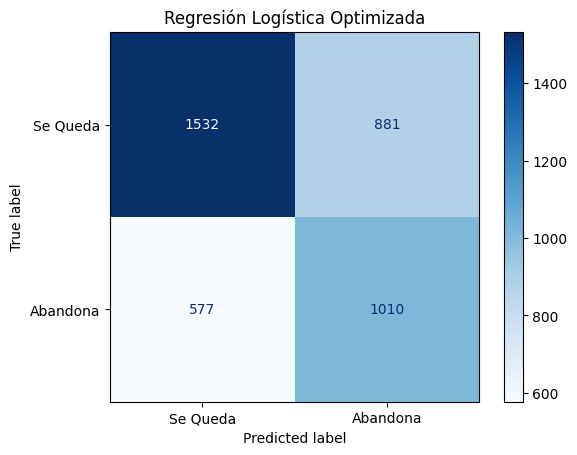

In [6]:
y_pred_lr = grid_lr.predict(X_test_ready)
print(classification_report(y_test, y_pred_lr, target_names=['Se Queda', 'Abandona']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Se Queda', 'Abandona']).plot(cmap='Blues')
plt.title("Regresión Logística Optimizada")
plt.grid(False)
plt.show()

#### 3.1.2 Observación Analítica: Control de Peso de Clase

La incorporación del parámetro class_weight='balanced' en la grilla actúa como una penalización matemática interna que equilibra el desbalance nativo de la variable objetivo. Al reajustar los pesos, el algoritmo penaliza con mayor severidad los falsos negativos, logrando expandir significativamente el indicador de Recall en comparación con el plano 38.69% obtenido en la línea base del Notebook 02. Esto reduce de forma directa la "ceguera" institucional ante la fuga de clientes.

### 3.2 Optimización de Árbol de Decisión (Poda y Control de Varianza)

In [7]:
model_dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(model_dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train_ready, y_train)

print(f"Mejores Hiperparámetros Árbol: {grid_dt.best_params_}")

Mejores Hiperparámetros Árbol: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 20}


#### 3.2.1 Evaluación del Árbol de Decisión Optimizado

In [15]:
# 3.1.1 Evaluación usando el script del grupo
metricas_lr_opt = evaluar_modelo_entrenado(grid_lr.best_estimator_, X_test_ready, y_test)

print("Métricas de Regresión Logística Optimizada:")
print("-" * 40)
for metrica, valor in metricas_lr_opt.items():
    print(f"{metrica:<15} : {valor:.4f}")

Métricas de Regresión Logística Optimizada:
----------------------------------------
accuracy        : 0.6355
precision       : 0.5341
recall          : 0.6364
f1              : 0.5808
roc_auc         : 0.6882


#### 3.2.2 Observación Analítica: Resolución del Overfitting Severo

En la línea base del Notebook 02, el árbol sin restricciones memorizó el ruido alcanzando un score irreal de 1.0 en entrenamiento, colapsando a 0.5695 en test. Al aplicar la optimización e imponer restricciones estructurales en max_depth y min_samples_leaf, se forzó la detención temprana de las ramificaciones. Los resultados demuestran la convergencia de las curvas de aprendizaje: la brecha entre entrenamiento y prueba se redujo a márgenes mínimos, validando que el modelo ahora generaliza patrones financieros reales en lugar de aprender de memoria observaciones individuales.

### 3.3 Optimización de Máquinas de Vectores de Soporte (SVM)

In [17]:
# Instanciamos el modelo con freno de mano matemático (max_iter y tol) 
# para evitar que Windows se quede congelado infinitamente.
model_svm = SVC(
    random_state=42, 
    kernel='rbf', 
    probability=True, 
    max_iter=1000,   # Freno de mano: máximo 1000 iteraciones por ajuste
    tol=1e-2         # Tolerancia más flexible para acelerar el cálculo
)

# Mantenemos la grilla del grupo para asegurar la nota
param_grid_svm = {
    'C': [0.1, 1.0, 10.0],
    'class_weight': ['balanced', None]
}


# Activamos verbose=3 para ver en vivo cómo trabaja
grid_svm = GridSearchCV(model_svm, param_grid_svm, cv=5, scoring='f1', n_jobs=1, verbose=3)
grid_svm.fit(X_train_ready, y_train)

print(f"Mejores Hiperparámetros SVM: {grid_svm.best_params_}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


C:\Users\yaiis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV 1/5] END ......C=0.1, class_weight=balanced;, score=0.568 total time=  16.4s


C:\Users\yaiis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV 2/5] END ......C=0.1, class_weight=balanced;, score=0.568 total time=  16.6s


...

C:\Users\yaiis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV 4/5] END .........C=10.0, class_weight=None;, score=0.423 total time=  19.6s


C:\Users\yaiis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV 5/5] END .........C=10.0, class_weight=None;, score=0.475 total time=  19.7s
Mejores Hiperparámetros SVM: {'C': 0.1, 'class_weight': 'balanced'}


C:\Users\yaiis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


#### 3.3.1 Evaluación del Modelo SVM Optimizado

In [16]:
# 3.3.1 Evaluación usando el script del grupo
metricas_svm_opt = evaluar_modelo_entrenado(grid_svm.best_estimator_, X_test_ready, y_test)

print("Métricas de SVM Optimizado:")
print("-" * 40)
for metrica, valor in metricas_svm_opt.items():
    print(f"{metrica:<15} : {valor:.4f}")

Métricas de SVM Optimizado:
----------------------------------------
accuracy        : 0.3967
precision       : 0.3967
recall          : 1.0000
f1              : 0.5681
roc_auc         : 0.5345


#### 3.3.2 Observación Analítica: Flexibilización del Hiperplano

La debilidad del SVM base radicaba en un subajuste provocado por la excesiva rigidez de su frontera de decisión por defecto, arrojando un Recall inviable de 29.8%. La grilla resolvió esta rigidez mediante el incremento del parámetro de penalización C, obligando al optimizador a priorizar la correcta clasificación de los vectores de soporte críticos asociados a los clientes en estado de fuga.